# Perceptryx Biometric Pipeline — Offline Evaluation

Evaluates face (vision) and voice (audio) recognition, plus fusion, against a labelled dataset.

**Expected directory layout**
```
known_data/
  PERSON_NAME/
    train/
      audio/   clip1.wav  clip2.wav ...   ← enrolled into gallery
      vision/  img1.jpg   img2.jpg  ...   ← enrolled into gallery
    val/
      audio/   ...                        ← used as evaluation probes
      vision/  ...                        ← used as evaluation probes
```
The person folder name **is** the ground-truth identity.
Gallery = `train/` split. Probes = `val/` split.

## 0 — Imports & config

In [41]:
import os, time, json, traceback, warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import torch
import torchaudio
import soundfile as sf
import cv2
from transformers import CLIPProcessor, CLIPModel
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve, auc,
    precision_recall_curve,
    average_precision_score,
)
from qdrant_client import QdrantClient
from qdrant_client.models import (
    Distance, VectorParams, PointStruct, Filter,
    FieldCondition, MatchValue,
)
import uuid

warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_theme(style='whitegrid', palette='muted')

# ── paths ──────────────────────────────────────────────────────────────────
# Root of the unified data tree (known_data/PERSON/train|val/audio|vision/)
KNOWN_DATA_DIR  = Path('./known_data')
GALLERY_SPLIT   = 'train'   # sub-folder used for enrollment
PROBE_SPLIT     = 'val'     # sub-folder used as evaluation probes
MODEL_PATH      = './triplet_run_2/best_triplet_model.pth'

# ── thresholds (mirror main service defaults) ──────────────────────────────
THRESHOLD_VISION = float(os.getenv('THRESHOLD_VISION', 0.70))
THRESHOLD_AUDIO  = float(os.getenv('THRESHOLD_AUDIO',  0.010))

# ── Qdrant (in-memory for eval — no running server needed) ─────────────────
USE_IN_MEMORY_QDRANT = True   # set False to use QDRANT_URL below
QDRANT_URL      = os.getenv('QDRANT_URL', 'http://localhost:6333')
ORGANIZATION_ID = 'eval_org'

FACE_COLLECTION  = 'eval_faces'
VOICE_COLLECTION = 'eval_voices'
FACE_DIM  = 512
VOICE_DIM = 128

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
print(f'Vision threshold: {THRESHOLD_VISION}  |  Audio threshold: {THRESHOLD_AUDIO}')

Device: cpu
Vision threshold: 0.7  |  Audio threshold: 0.01


## 1 — Helpers (copied verbatim from main service)

In [42]:
def norm(v):
    v = np.array(v, dtype=np.float32).flatten()
    return v / (np.linalg.norm(v) + 1e-9)

def safe_vector(v, dim):
    v = np.array(v, dtype=np.float32).flatten()
    if v.shape[0] > dim:  v = v[:dim]
    else:                  v = np.pad(v, (0, dim - v.shape[0]))
    return v.astype(np.float32)

def deterministic_uuid(value):
    return str(uuid.uuid5(uuid.NAMESPACE_DNS, value))

def load_audio(path):
    try:
        wav, sr = sf.read(path)
    except Exception:
        wav, sr = torchaudio.load(path)
    wav = torch.tensor(np.array(wav)).float()
    if wav.ndim == 2:
        wav = wav.mean(dim=1)
    wav = wav.unsqueeze(0)
    if sr != 16000:
        wav = torchaudio.functional.resample(wav, sr, 16000)
    return wav

def vote(matches, threshold):
    if not matches:
        return 'unknown', 0.0, []
    accepted = [m for m in matches if float(m.score) >= threshold]
    if not accepted:
        return 'unknown', float(matches[0].score), matches
    person_votes = Counter(m.payload['person_id'] for m in accepted)
    winner_id, _ = person_votes.most_common(1)[0]
    winner_matches = [m for m in accepted if m.payload['person_id'] == winner_id]
    best  = max(winner_matches, key=lambda m: float(m.score))
    return best.payload.get('person_id', 'unknown'), float(best.score), matches

print('Helpers loaded.')

Helpers loaded.


## 2 — Model classes

In [43]:
class VoiceNetEmbedding(torch.nn.Module):
    def __init__(self, embedding_dim=128):
        super().__init__()
        def block(i, o):
            return torch.nn.Sequential(
                torch.nn.Conv2d(i, o, 3, padding=1),
                torch.nn.BatchNorm2d(o),
                torch.nn.ReLU(),
                torch.nn.MaxPool2d(2),
            )
        self.features = torch.nn.Sequential(
            block(1,32), block(32,64), block(64,128), block(128,256), block(256,256)
        )
        self.head = torch.nn.Sequential(
            torch.nn.AdaptiveAvgPool2d((1,1)),
            torch.nn.Flatten(),
            torch.nn.Linear(256, 256),
            torch.nn.ReLU(),
            torch.nn.Linear(256, embedding_dim),
        )
    def forward(self, x):
        return self.head(self.features(x))

print('VoiceNetEmbedding defined.')

VoiceNetEmbedding defined.


## 3 — Qdrant store wrapper

In [44]:
if USE_IN_MEMORY_QDRANT:
    client = QdrantClient(':memory:')
else:
    client = QdrantClient(url=QDRANT_URL)

def _ensure(name, dim):
    if client.collection_exists(name):
        client.delete_collection(name)
    client.create_collection(
        collection_name=name,
        vectors_config=VectorParams(size=dim, distance=Distance.COSINE)
    )

def enroll(collection, person_id, embedding, dim):
    embedding = safe_vector(norm(embedding), dim)
    sid = f'{collection}_{ORGANIZATION_ID}_{person_id}_centroid'
    client.upsert(
        collection_name=collection,
        points=[PointStruct(
            id=deterministic_uuid(sid),
            vector=embedding.tolist(),
            payload={
                'person_id': person_id,
                'organization_id': ORGANIZATION_ID,
                'active': True,
            }
        )],
        wait=True,
    )

def recognize(collection, embedding, dim, threshold, limit=5):
    embedding = safe_vector(norm(embedding), dim)
    q_filter = Filter(must=[
        FieldCondition(key='organization_id', match=MatchValue(value=ORGANIZATION_ID)),
        FieldCondition(key='active',          match=MatchValue(value=True)),
    ])
    matches = client.query_points(
        collection_name=collection,
        query=embedding.tolist(),
        query_filter=q_filter,
        with_payload=True,
        limit=limit,
    ).points
    return vote(matches, threshold)

print('Qdrant store ready.')

Qdrant store ready.


## 4 — Load CLIP (vision model)

In [45]:
clip_processor = CLIPProcessor.from_pretrained('openai/clip-vit-base-patch32')
clip_model     = CLIPModel.from_pretrained('openai/clip-vit-base-patch32').to(DEVICE).eval()

def embed_face(image_rgb):
    inputs = clip_processor(images=image_rgb, return_tensors='pt')
    pv = inputs['pixel_values'].to(DEVICE)
    with torch.no_grad():
        out = clip_model.get_image_features(pixel_values=pv)
    if isinstance(out, torch.Tensor): emb = out
    elif hasattr(out, 'image_embeds') and out.image_embeds is not None: emb = out.image_embeds
    else: emb = out[0]
    return emb.detach().cpu().numpy().flatten()

print('CLIP loaded.')

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 18547.53it/s]

CLIP loaded.


## 5 — Load VoiceNet

In [46]:
def load_voice_model(path, device):
    model = VoiceNetEmbedding(embedding_dim=VOICE_DIM).to(device)
    state = torch.load(path, map_location=device)
    fixed = {k.replace('embedding_head', 'head'): v for k, v in state.items()}
    model.load_state_dict(fixed, strict=True)
    model.eval()
    return model

mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=16000, n_mels=128, n_fft=1024, hop_length=512
).to(DEVICE)
db_transform = torchaudio.transforms.AmplitudeToDB().to(DEVICE)

def embed_voice(model, wav):
    wav = wav.to(DEVICE)
    with torch.no_grad():
        spec = mel_transform(wav)
        spec = db_transform(spec).unsqueeze(0)
        spec = torch.nn.functional.interpolate(spec, size=(128,128), mode='bilinear', align_corners=False)
        spec = (spec - spec.mean()) / (spec.std() + 1e-7)
        emb = model(spec).cpu().numpy().flatten()
    return safe_vector(norm(emb), VOICE_DIM)

if Path(MODEL_PATH).exists():
    voice_model = load_voice_model(MODEL_PATH, DEVICE)
    print(f'VoiceNet loaded from {MODEL_PATH}')
else:
    voice_model = None
    print(f'⚠  VoiceNet model not found at {MODEL_PATH} — audio evaluation will be skipped.')

VoiceNet loaded from ./triplet_run_2/best_triplet_model.pth


## 6 — Enroll gallery (known_data/PERSON/train/)

In [47]:
_ensure(FACE_COLLECTION,  FACE_DIM)
_ensure(VOICE_COLLECTION, VOICE_DIM)

IMG_EXT   = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')
AUDIO_EXT = ('.wav', '.mp3', '.flac', '.ogg', '.m4a')

enrolled_identities_vision = []
enrolled_identities_audio  = []

if not KNOWN_DATA_DIR.exists():
    print(f'ERROR: {KNOWN_DATA_DIR} not found — check KNOWN_DATA_DIR path')
else:
    persons = sorted(p for p in KNOWN_DATA_DIR.iterdir() if p.is_dir())
    print(f'Found {len(persons)} person folders under {KNOWN_DATA_DIR}')

    for person_dir in persons:
        person_id   = person_dir.name
        train_dir   = person_dir / GALLERY_SPLIT
        vision_dir  = train_dir / 'vision'
        audio_dir   = train_dir / 'audio'

        # ── face gallery ───────────────────────────────────────────────────
        if vision_dir.exists():
            embs = []
            for f in sorted(vision_dir.iterdir()):
                if f.suffix.lower() not in IMG_EXT: continue
                img = cv2.imread(str(f))
                if img is None: continue
                try:
                    embs.append(embed_face(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)))
                except Exception as e:
                    print(f'  [vision] skip {f.name}: {e}')
            if embs:
                centroid = norm(np.mean(embs, axis=0))
                enroll(FACE_COLLECTION, person_id, centroid, FACE_DIM)
                enrolled_identities_vision.append(person_id)
                print(f'  [vision] enrolled {person_id:<20} ({len(embs)} images from {vision_dir})')
            else:
                print(f'  [vision] no images found for {person_id} in {vision_dir}')
        else:
            print(f'  [vision] missing {vision_dir}')

        # ── voice gallery ──────────────────────────────────────────────────
        if audio_dir.exists() and voice_model:
            embs = []
            for f in sorted(audio_dir.iterdir()):
                if f.suffix.lower() not in AUDIO_EXT: continue
                try:
                    wav = load_audio(str(f))
                    embs.append(embed_voice(voice_model, wav))
                except Exception as e:
                    print(f'  [audio] skip {f.name}: {e}')
            if embs:
                centroid = norm(np.mean(embs, axis=0))
                enroll(VOICE_COLLECTION, person_id, centroid, VOICE_DIM)
                enrolled_identities_audio.append(person_id)
                print(f'  [audio]  enrolled {person_id:<20} ({len(embs)} clips  from {audio_dir})')
            else:
                print(f'  [audio]  no audio found for {person_id} in {audio_dir}')
        elif not voice_model:
            pass  # model not loaded — warning already printed in cell 5
        else:
            print(f'  [audio]  missing {audio_dir}')

print(f'\nGallery totals: {len(enrolled_identities_vision)} faces | {len(enrolled_identities_audio)} voices')

Found 5 person folders under known_data
  [vision] enrolled CONOR MCGREGOR       (25 images from known_data/CONOR MCGREGOR/train/vision)
  [audio]  enrolled CONOR MCGREGOR       (20 clips  from known_data/CONOR MCGREGOR/train/audio)
  [vision] enrolled KHABIB               (25 images from known_data/KHABIB/train/vision)
  [audio]  enrolled KHABIB               (9 clips  from known_data/KHABIB/train/audio)
  [vision] enrolled OBAMA                (25 images from known_data/OBAMA/train/vision)
  [audio]  enrolled OBAMA                (20 clips  from known_data/OBAMA/train/audio)
  [vision] enrolled PAPA                 (25 images from known_data/PAPA/train/vision)
  [audio]  enrolled PAPA                 (20 clips  from known_data/PAPA/train/audio)
  [vision] enrolled ZORAN MILANOVIC      (25 images from known_data/ZORAN MILANOVIC/train/vision)
  [audio]  enrolled ZORAN MILANOVIC      (8 clips  from known_data/ZORAN MILANOVIC/train/audio)

Gallery totals: 5 faces | 5 voices


## 7 — Run probes (known_data/PERSON/val/)

In [48]:
vision_results = []   # {gt, pred, score, file}
audio_results  = []

if not KNOWN_DATA_DIR.exists():
    print(f'ERROR: {KNOWN_DATA_DIR} not found')
else:
    persons = sorted(p for p in KNOWN_DATA_DIR.iterdir() if p.is_dir())

    for person_dir in persons:
        person_id  = person_dir.name
        val_dir    = person_dir / PROBE_SPLIT
        vision_dir = val_dir / 'vision'
        audio_dir  = val_dir / 'audio'

        # ── vision probes ──────────────────────────────────────────────────
        if vision_dir.exists():
            files = [f for f in sorted(vision_dir.iterdir()) if f.suffix.lower() in IMG_EXT]
            for f in files:
                img = cv2.imread(str(f))
                if img is None: continue
                try:
                    emb = embed_face(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
                    pred, score, _ = recognize(FACE_COLLECTION, emb, FACE_DIM, THRESHOLD_VISION)
                    vision_results.append({'gt': person_id, 'pred': pred, 'score': score, 'file': str(f)})
                except Exception as e:
                    print(f'  [vision] error {f.name}: {e}')
        # (silently skip missing val/vision — person may only have audio)

        # ── audio probes ───────────────────────────────────────────────────
        if audio_dir.exists() and voice_model:
            files = [f for f in sorted(audio_dir.iterdir()) if f.suffix.lower() in AUDIO_EXT]
            for f in files:
                try:
                    wav = load_audio(str(f))
                    emb = embed_voice(voice_model, wav)
                    pred, score, _ = recognize(VOICE_COLLECTION, emb, VOICE_DIM, THRESHOLD_AUDIO)
                    audio_results.append({'gt': person_id, 'pred': pred, 'score': score, 'file': str(f)})
                except Exception as e:
                    print(f'  [audio]  error {f.name}: {e}')

print(f'Probe totals — vision: {len(vision_results)} | audio: {len(audio_results)}')
if not vision_results: print('  ⚠  No vision probes found — check that val/vision/ exists under each person')
if not audio_results:  print('  ⚠  No audio  probes found — check that val/audio/  exists under each person')

Probe totals — vision: 125 | audio: 77


## 8 — Core metrics per modality

In [50]:
def compute_metrics(results, label):
    if not results:
        print(f'[{label}] No results to evaluate.')
        return None

    df = pd.DataFrame(results)
    y_true = df['gt'].tolist()
    y_pred = df['pred'].tolist()

    # All possible labels (union of gt and pred, ordered)
    labels = sorted(set(y_true) | set(y_pred))

    print(f'\n{'='*60}')
    print(f'  {label.upper()} — Classification Report')
    print(f'{'='*60}')
    print(classification_report(y_true, y_pred, labels=labels, zero_division=0))

    # ── binary view: known vs unknown ─────────────────────────────────────
    # treat any non-"unknown" prediction/gt as positive (= "recognised")
    y_true_bin = [0 if g == 'unknown' else 1 for g in y_true]
    y_pred_bin = [0 if p == 'unknown' else 1 for p in y_pred]
    scores     = df['score'].tolist()

    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    print(f'Binary (known=1 / unknown=0):')
    print(f'  Accuracy : {accuracy_score(y_true_bin, y_pred_bin):.4f}')
    print(f'  Precision: {precision_score(y_true_bin, y_pred_bin, zero_division=0):.4f}')
    print(f'  Recall   : {recall_score(y_true_bin, y_pred_bin, zero_division=0):.4f}')
    print(f'  F1       : {f1_score(y_true_bin, y_pred_bin, zero_division=0):.4f}')

    # False Acceptance Rate / False Rejection Rate
    tp = sum(1 for t,p in zip(y_true_bin, y_pred_bin) if t==1 and p==1)
    tn = sum(1 for t,p in zip(y_true_bin, y_pred_bin) if t==0 and p==0)
    fp = sum(1 for t,p in zip(y_true_bin, y_pred_bin) if t==0 and p==1)
    fn = sum(1 for t,p in zip(y_true_bin, y_pred_bin) if t==1 and p==0)

    far = fp / (fp + tn + 1e-9)   # False Acceptance Rate
    frr = fn / (fn + tp + 1e-9)   # False Rejection Rate
    print(f'  FAR (False Accept): {far:.4f}   FRR (False Reject): {frr:.4f}')

    return df, labels, y_true_bin, y_pred_bin, scores

vis_out = compute_metrics(vision_results, 'vision')
aud_out = compute_metrics(audio_results,  'audio')


  VISION — Classification Report
                 precision    recall  f1-score   support

 CONOR MCGREGOR       1.00      1.00      1.00        25
         KHABIB       1.00      1.00      1.00        25
          OBAMA       1.00      0.72      0.84        25
           PAPA       1.00      1.00      1.00        25
ZORAN MILANOVIC       1.00      1.00      1.00        25
        unknown       0.00      0.00      0.00         0

       accuracy                           0.94       125
      macro avg       0.83      0.79      0.81       125
   weighted avg       1.00      0.94      0.97       125

Binary (known=1 / unknown=0):
  Accuracy : 0.9440
  Precision: 1.0000
  Recall   : 0.9440
  F1       : 0.9712
  FAR (False Accept): 0.0000   FRR (False Reject): 0.0560

  AUDIO — Classification Report
                 precision    recall  f1-score   support

 CONOR MCGREGOR       1.00      0.95      0.97        20
         KHABIB       0.90      1.00      0.95         9
          OBAMA     

## 9 — Confusion matrices

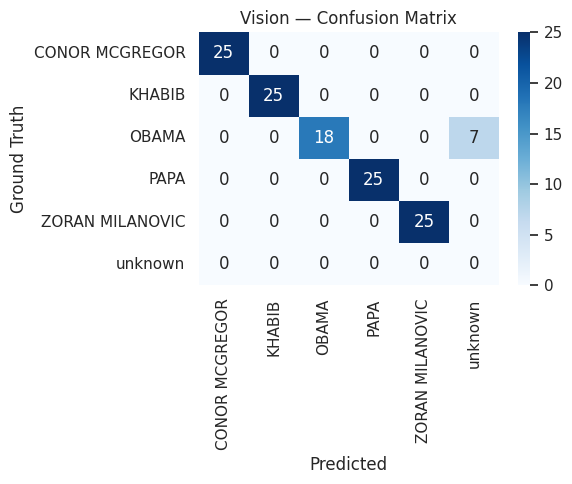

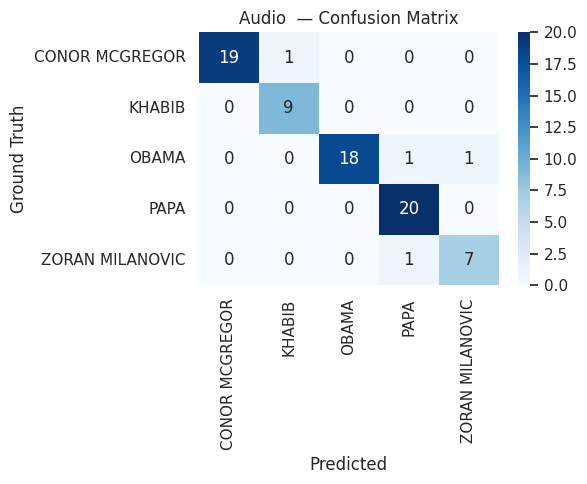

In [51]:
def plot_confusion(results, labels, title):
    if results is None: return
    df, lbl_list, *_ = results
    cm = confusion_matrix(df['gt'], df['pred'], labels=lbl_list)
    fig, ax = plt.subplots(figsize=(max(6, len(lbl_list)), max(5, len(lbl_list)-1)))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=lbl_list, yticklabels=lbl_list, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Ground Truth')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

plot_confusion(vis_out, None, 'Vision — Confusion Matrix')
plot_confusion(aud_out, None, 'Audio  — Confusion Matrix')

## 10 — ROC & Precision–Recall curves

[Vision] Binary known/unknown ROC/PR skipped — closed-set setup has no unknown class.
[Vision] Plotting one-vs-rest ROC/PR for 5 classes.


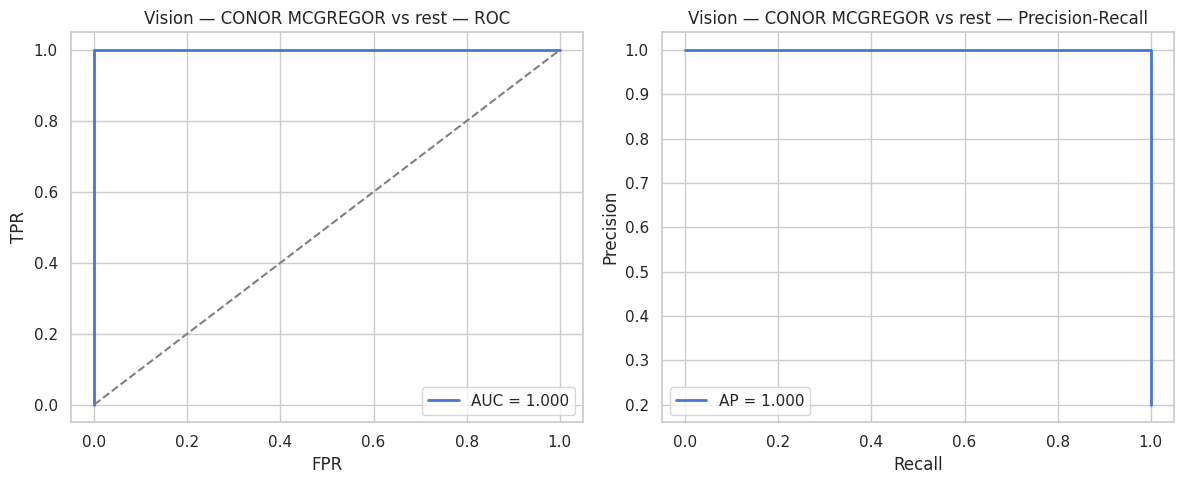

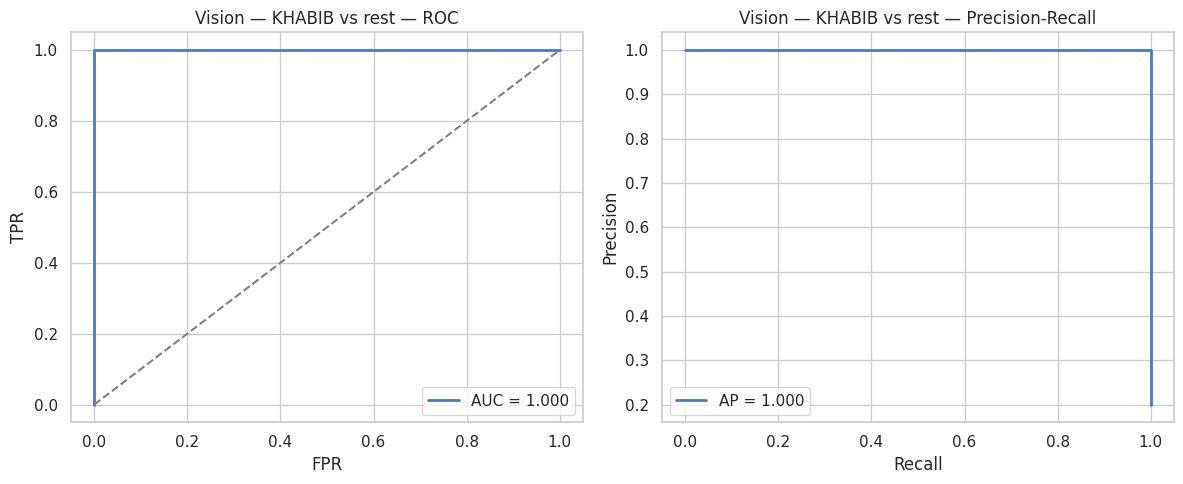

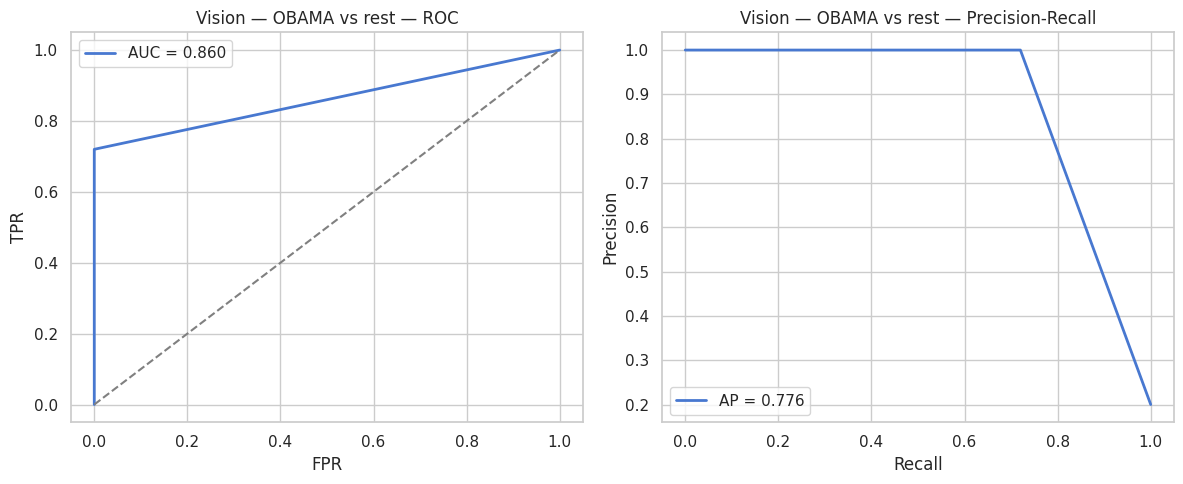

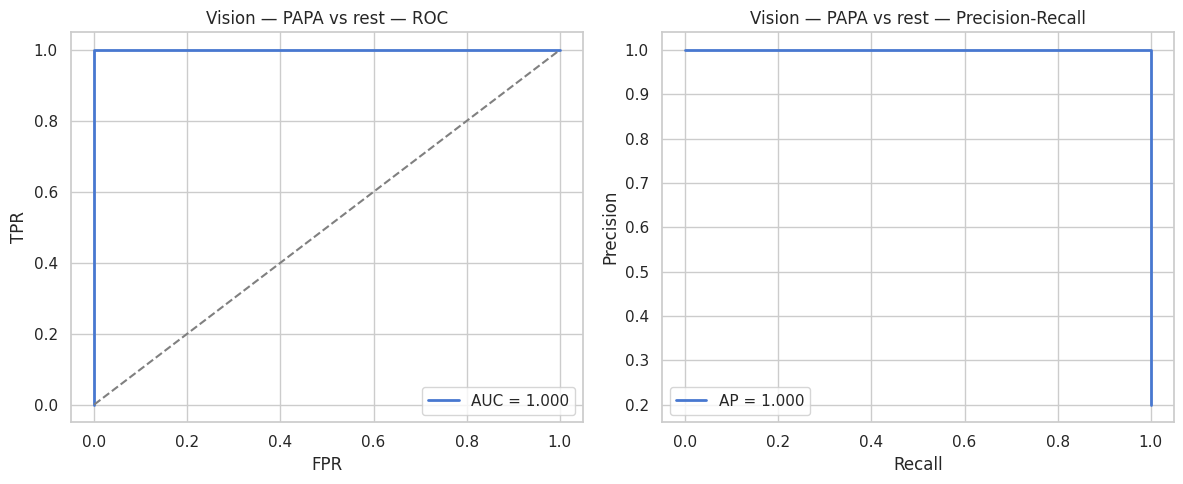

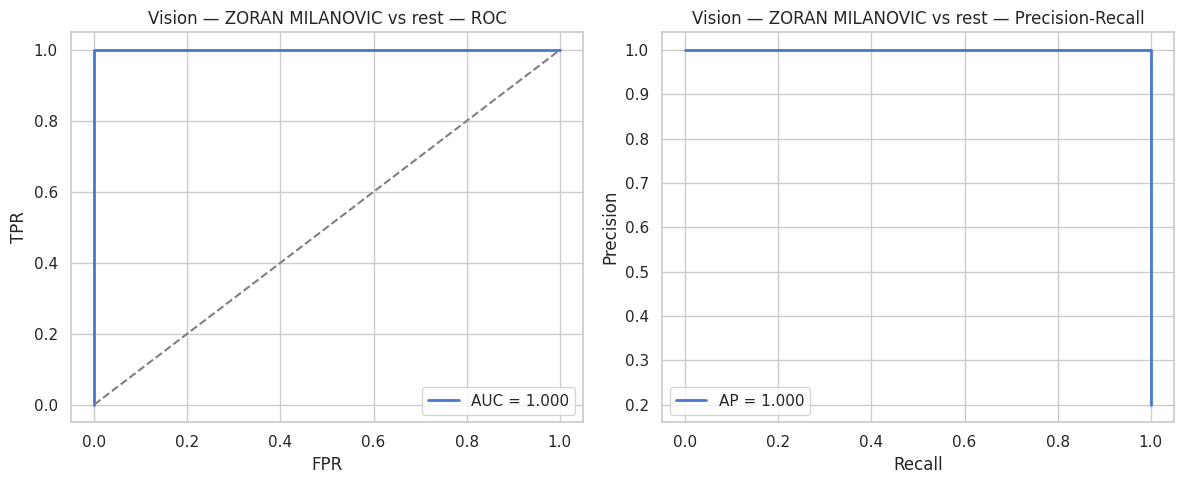


[Vision] One-vs-rest summary:


,class,positives,negatives,roc_auc,average_precision,score_source
0,CONOR MCGREGOR,25,100,1.00,1.000,fallback: top-1 pred + score
1,KHABIB,25,100,1.00,1.000,fallback: top-1 pred + score
2,PAPA,25,100,1.00,1.000,fallback: top-1 pred + score
3,ZORAN MILANOVIC,25,100,1.00,1.000,fallback: top-1 pred + score
4,OBAMA,25,100,0.86,0.776,fallback: top-1 pred + score


[Audio] Binary known/unknown ROC/PR skipped — closed-set setup has no unknown class.
[Audio] Plotting one-vs-rest ROC/PR for 5 classes.


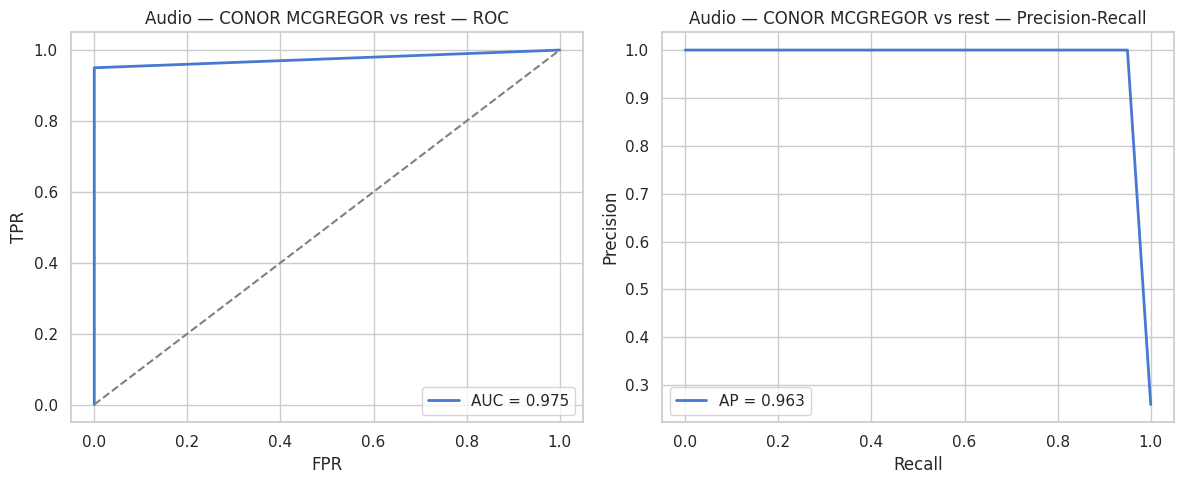

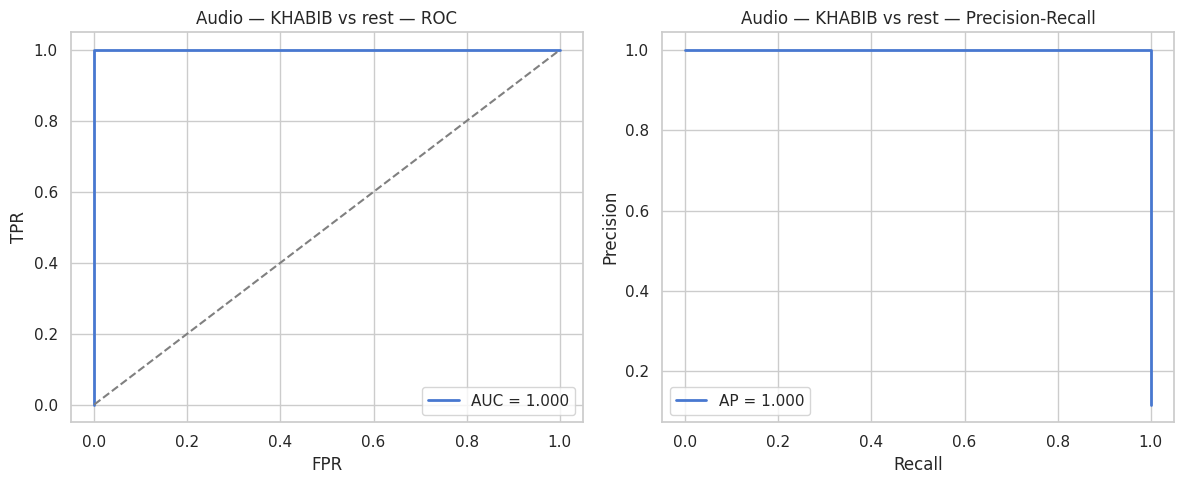

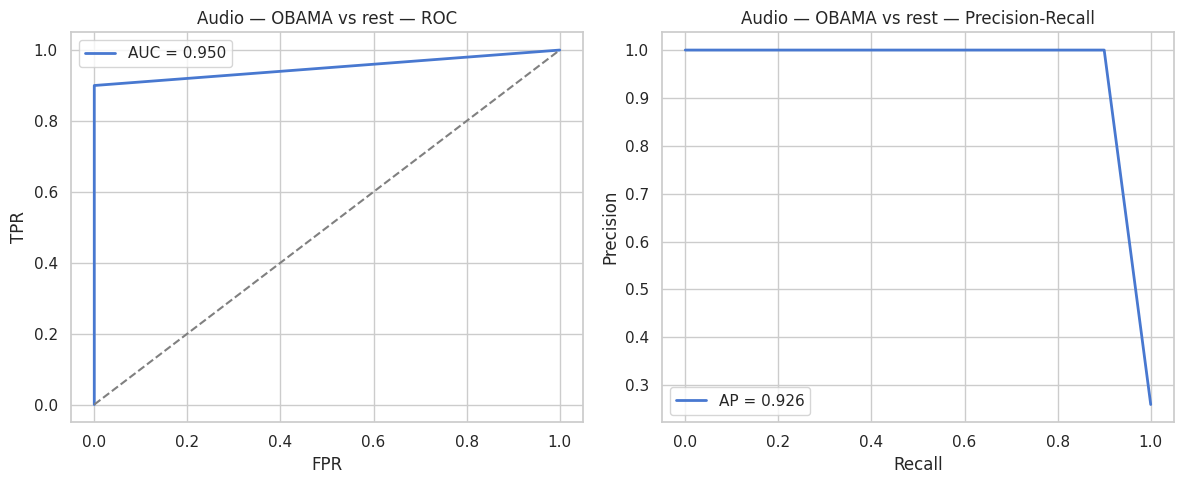

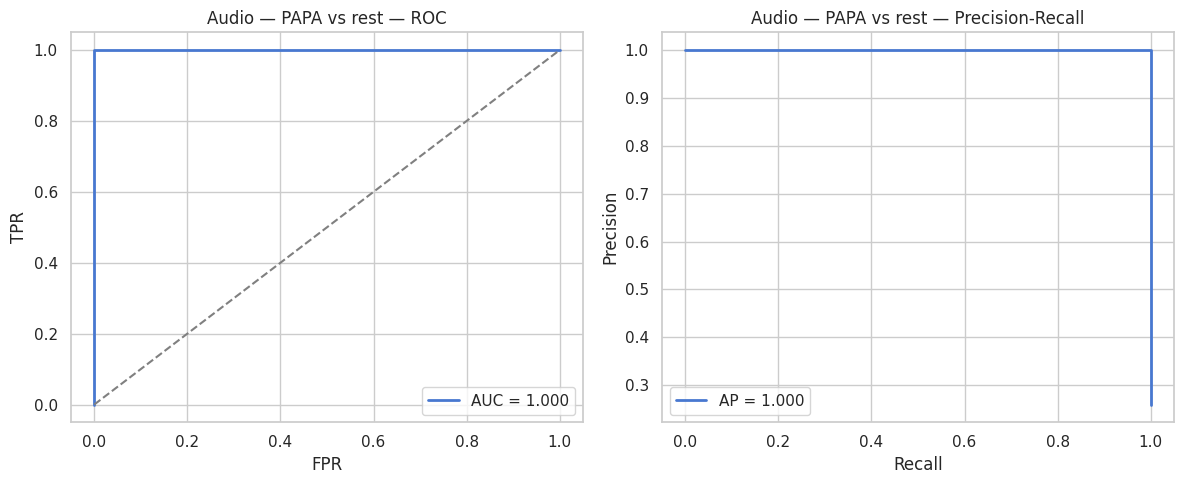

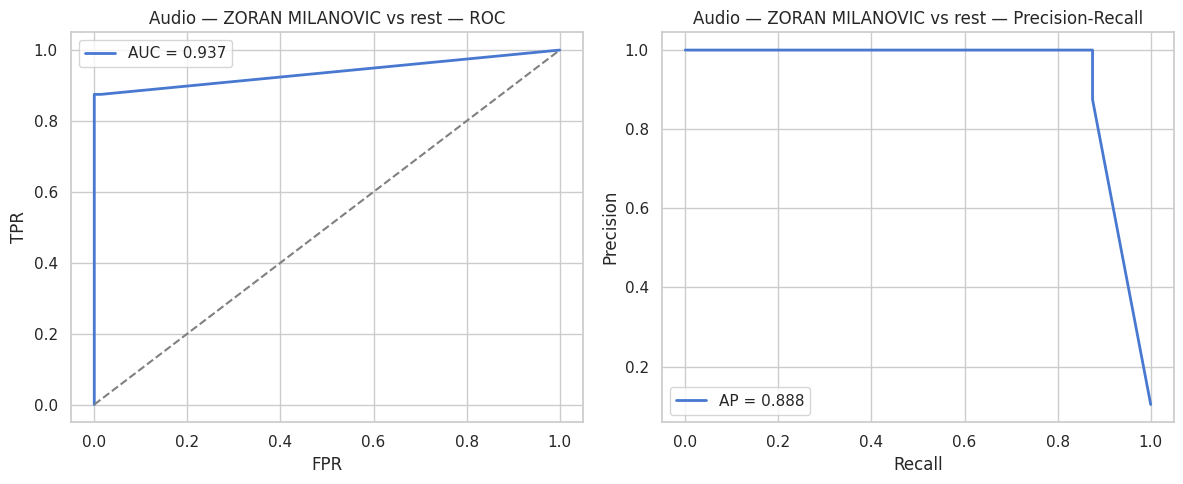


[Audio] One-vs-rest summary:


,class,positives,negatives,roc_auc,average_precision,score_source
0,KHABIB,9,68,1.000000,1.000000,fallback: top-1 pred + score
1,PAPA,20,57,1.000000,1.000000,fallback: top-1 pred + score
2,CONOR MCGREGOR,20,57,0.975000,0.962987,fallback: top-1 pred + score
3,OBAMA,20,57,0.950000,0.925974,fallback: top-1 pred + score
4,ZORAN MILANOVIC,8,69,0.936594,0.887987,fallback: top-1 pred + score


In [52]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
)


def plot_roc_pr(result_tuple, title, higher_score_is_better=True):
    if result_tuple is None:
        return

    df, labels, y_true_bin, y_pred_bin, scores = result_tuple

    def normalize_name(x):
        return re.sub(r'[^a-z0-9]+', '_', str(x).strip().lower()).strip('_')

    def show_df(x):
        try:
            display(x)
        except NameError:
            print(x)

    def bad_score_value(values):
        values = np.asarray(values, dtype=float)
        finite = values[np.isfinite(values)]

        if len(finite) == 0:
            return -1e9 if higher_score_is_better else 1e9

        eps = 1e-9
        return finite.min() - eps if higher_score_is_better else finite.max() + eps

    def orient_scores(values):
        values = np.asarray(values, dtype=float)
        return values if higher_score_is_better else -values

    def extract_from_dict(obj, cls):
        if not isinstance(obj, dict):
            return np.nan

        if cls in obj:
            return float(obj[cls])

        cls_norm = normalize_name(cls)

        for k, v in obj.items():
            if normalize_name(k) == cls_norm:
                return float(v)

        return np.nan

    def extract_from_matches(obj, cls):
        if not isinstance(obj, list):
            return np.nan

        cls_norm = normalize_name(cls)
        best = np.nan

        for item in obj:
            if not isinstance(item, dict):
                continue

            person = (
                item.get("person_id")
                or item.get("identity")
                or item.get("label")
                or item.get("class")
                or item.get("name")
            )

            if person is None or normalize_name(person) != cls_norm:
                continue

            val = (
                item.get("score")
                if item.get("score") is not None
                else item.get("similarity")
                if item.get("similarity") is not None
                else item.get("distance")
            )

            if val is None:
                continue

            val = float(val)

            if np.isnan(best):
                best = val
            elif higher_score_is_better:
                best = max(best, val)
            else:
                best = min(best, val)

        return best

    def get_class_scores(cls):
        cls_norm = normalize_name(cls)

        direct_candidates = [
            f"score_{cls}",
            f"scores_{cls}",
            f"prob_{cls}",
            f"sim_{cls}",
            f"similarity_{cls}",
            f"distance_{cls}",
            f"score_{cls_norm}",
            f"scores_{cls_norm}",
            f"prob_{cls_norm}",
            f"sim_{cls_norm}",
            f"similarity_{cls_norm}",
            f"distance_{cls_norm}",
        ]

        normalized_cols = {normalize_name(c): c for c in df.columns}

        for candidate in direct_candidates:
            candidate_norm = normalize_name(candidate)
            if candidate_norm in normalized_cols:
                col = normalized_cols[candidate_norm]
                vals = pd.to_numeric(df[col], errors="coerce").to_numpy(dtype=float)
                fill = bad_score_value(vals)
                vals = np.nan_to_num(vals, nan=fill)
                return orient_scores(vals), "per-class column"

        dict_like_cols = [
            "scores",
            "class_scores",
            "identity_scores",
            "scores_by_class",
            "score_by_class",
            "class_score",
        ]

        for col in dict_like_cols:
            if col not in df.columns:
                continue

            vals = df[col].apply(lambda x: extract_from_dict(x, cls)).to_numpy(dtype=float)

            if not np.isnan(vals).all():
                fill = bad_score_value(vals)
                vals = np.nan_to_num(vals, nan=fill)
                return orient_scores(vals), f"dict column: {col}"

        match_like_cols = [
            "matches",
            "top_matches",
            "neighbors",
            "nearest",
            "nearest_neighbors",
            "raw_matches",
        ]

        for col in match_like_cols:
            if col not in df.columns:
                continue

            vals = df[col].apply(lambda x: extract_from_matches(x, cls)).to_numpy(dtype=float)

            if not np.isnan(vals).all():
                fill = bad_score_value(vals)
                vals = np.nan_to_num(vals, nan=fill)
                return orient_scores(vals), f"matches column: {col}"

        if "pred" not in df.columns:
            return None, None

        base_scores = (
            pd.to_numeric(df["score"], errors="coerce").to_numpy(dtype=float)
            if "score" in df.columns
            else np.asarray(scores, dtype=float)
        )

        fill = bad_score_value(base_scores)
        vals = np.where(df["pred"].astype(str).to_numpy() == str(cls), base_scores, fill)

        return orient_scores(vals), "fallback: top-1 pred + score"

    def plot_pair(y_true, y_score, main_title):
        fpr, tpr, _ = roc_curve(y_true, y_score)
        roc_auc = auc(fpr, tpr)

        prec, rec, _ = precision_recall_curve(y_true, y_score)
        ap = average_precision_score(y_true, y_score)

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        axes[0].plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.3f}")
        axes[0].plot([0, 1], [0, 1], "--", color="grey")
        axes[0].set_xlabel("FPR")
        axes[0].set_ylabel("TPR")
        axes[0].set_title(f"{main_title} — ROC")
        axes[0].legend()

        axes[1].plot(rec, prec, lw=2, label=f"AP = {ap:.3f}")
        axes[1].set_xlabel("Recall")
        axes[1].set_ylabel("Precision")
        axes[1].set_title(f"{main_title} — Precision-Recall")
        axes[1].legend()

        plt.tight_layout()
        plt.show()

        return roc_auc, ap

    binary_scores = orient_scores(np.asarray(scores, dtype=float))

    if len(set(y_true_bin)) < 2:
        print(f"[{title}] Binary known/unknown ROC/PR skipped — closed-set setup has no unknown class.")
    else:
        plot_pair(
            np.asarray(y_true_bin, dtype=int),
            binary_scores,
            f"{title} — Binary known/unknown"
        )

    if "gt" not in df.columns:
        print(f"[{title}] Missing 'gt' column. Cannot plot one-vs-rest ROC/PR.")
        return

    unknown_labels = {"unknown", "none", "unrecognized", "negative", "negatives", "impostor"}

    class_names = sorted([
        c for c in df["gt"].astype(str).unique()
        if normalize_name(c) not in unknown_labels
    ])

    if len(class_names) < 2:
        print(f"[{title}] Need at least two closed-set classes for one-vs-rest ROC/PR.")
        return

    print(f"[{title}] Plotting one-vs-rest ROC/PR for {len(class_names)} classes.")

    summary_rows = []

    for cls in class_names:
        y_true = (df["gt"].astype(str).to_numpy() == str(cls)).astype(int)

        if len(set(y_true)) < 2:
            print(f"[{title}] Skipping {cls}: no positives or no negatives.")
            continue

        y_score, source = get_class_scores(cls)

        if y_score is None:
            print(f"[{title}] Skipping {cls}: no usable score column.")
            continue

        roc_auc, ap = plot_pair(
            y_true,
            y_score,
            f"{title} — {cls} vs rest"
        )

        summary_rows.append({
            "class": cls,
            "positives": int(y_true.sum()),
            "negatives": int(len(y_true) - y_true.sum()),
            "roc_auc": roc_auc,
            "average_precision": ap,
            "score_source": source,
        })

    summary = pd.DataFrame(summary_rows)

    if not summary.empty:
        summary = summary.sort_values("roc_auc", ascending=False).reset_index(drop=True)
        print(f"\n[{title}] One-vs-rest summary:")
        show_df(summary)

    return summary


vis_ovr_summary = plot_roc_pr(vis_out, "Vision")
aud_ovr_summary = plot_roc_pr(aud_out, "Audio")

## 11 — Score distributions

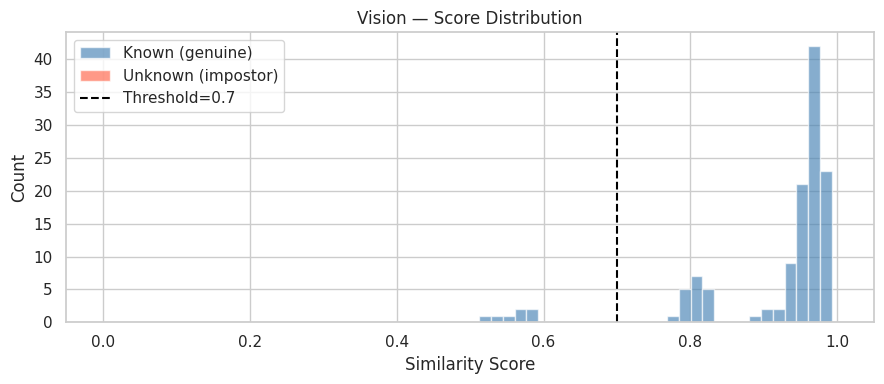

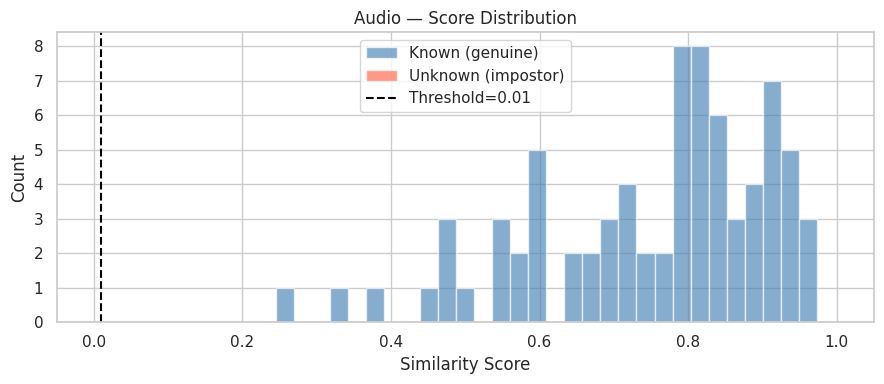

In [53]:
def plot_score_dist(result_tuple, threshold, title):
    if result_tuple is None: return
    df, *_ = result_tuple
    fig, ax = plt.subplots(figsize=(9, 4))
    known_mask = df['gt'] != 'unknown'
    ax.hist(df.loc[ known_mask, 'score'], bins=30, alpha=0.65, label='Known (genuine)',  color='steelblue')
    ax.hist(df.loc[~known_mask, 'score'], bins=30, alpha=0.65, label='Unknown (impostor)',color='tomato')
    ax.axvline(threshold, color='black', linestyle='--', linewidth=1.5, label=f'Threshold={threshold}')
    ax.set_xlabel('Similarity Score'); ax.set_ylabel('Count')
    ax.set_title(f'{title} — Score Distribution')
    ax.legend(); plt.tight_layout(); plt.show()

plot_score_dist(vis_out, THRESHOLD_VISION, 'Vision')
plot_score_dist(aud_out, THRESHOLD_AUDIO,  'Audio')

## 12 — Threshold sweep (find optimal operating point)

In [55]:
from sklearn.metrics import f1_score as sk_f1

def threshold_sweep(result_tuple, title, n_steps=200):
    if result_tuple is None: return
    df, _, y_true_bin, _, scores = result_tuple
    if len(set(y_true_bin)) < 2:
        print(f'[{title}] Need both classes for sweep.'); return

    thresholds = np.linspace(min(scores), max(scores), n_steps)
    f1s, fars, frrs = [], [], []

    for t in thresholds:
        preds = [1 if s >= t else 0 for s in scores]
        f1s.append(sk_f1(y_true_bin, preds, zero_division=0))
        tp = sum(1 for yt,yp in zip(y_true_bin,preds) if yt==1 and yp==1)
        tn = sum(1 for yt,yp in zip(y_true_bin,preds) if yt==0 and yp==0)
        fp = sum(1 for yt,yp in zip(y_true_bin,preds) if yt==0 and yp==1)
        fn = sum(1 for yt,yp in zip(y_true_bin,preds) if yt==1 and yp==0)
        fars.append(fp / (fp+tn+1e-9))
        frrs.append(fn / (fn+tp+1e-9))

    best_idx = int(np.argmax(f1s))
    best_t   = thresholds[best_idx]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(thresholds, f1s, label='F1')
    axes[0].axvline(best_t, color='green', linestyle='--', label=f'Best F1 @ {best_t:.4f}')
    axes[0].set_xlabel('Threshold'); axes[0].set_ylabel('F1'); axes[0].set_title(f'{title} — F1 vs Threshold'); axes[0].legend()

    axes[1].plot(thresholds, fars, label='FAR', color='tomato')
    axes[1].plot(thresholds, frrs, label='FRR', color='steelblue')
    axes[1].axvline(best_t, color='green', linestyle='--', label=f'Best F1 @ {best_t:.4f}')

    # EER
    eer_idx = int(np.argmin(np.abs(np.array(fars) - np.array(frrs))))
    eer = (fars[eer_idx] + frrs[eer_idx]) / 2
    axes[1].axvline(thresholds[eer_idx], color='purple', linestyle=':', label=f'EER={eer:.4f} @ {thresholds[eer_idx]:.4f}')
    axes[1].set_xlabel('Threshold'); axes[1].set_ylabel('Rate'); axes[1].set_title(f'{title} — FAR / FRR'); axes[1].legend()

    plt.tight_layout(); plt.show()
    print(f'[{title}] Best F1 threshold: {best_t:.4f}  |  EER: {eer:.4f} @ {thresholds[eer_idx]:.4f}')

threshold_sweep(vis_out, 'Vision')
threshold_sweep(aud_out, 'Audio')

[Vision] Need both classes for sweep.
[Audio] Need both classes for sweep.


## 13 — Per-identity breakdown

In [56]:
def per_identity_table(result_tuple, label):
    if result_tuple is None: return
    df, *_ = result_tuple
    rows = []
    for identity, grp in df.groupby('gt'):
        correct = (grp['pred'] == identity).sum()
        total   = len(grp)
        rows.append({
            'Identity'     : identity,
            'Total Probes' : total,
            'Correct'      : correct,
            'Wrong'        : total - correct,
            'Accuracy'     : round(correct / total, 4),
            'Avg Score'    : round(grp['score'].mean(), 4),
            'Min Score'    : round(grp['score'].min(),  4),
            'Max Score'    : round(grp['score'].max(),  4),
        })
    tbl = pd.DataFrame(rows).sort_values('Accuracy')
    print(f'\n── {label} per-identity ──')
    display(tbl)
    return tbl

vis_table = per_identity_table(vis_out, 'Vision')
aud_table = per_identity_table(aud_out, 'Audio')


── Vision per-identity ──


,Identity,Total Probes,Correct,Wrong,Accuracy,Avg Score,Min Score,Max Score
2,OBAMA,25,18,7,0.72,0.7365,0.5128,0.8254
0,CONOR MCGREGOR,25,25,0,1.00,0.9478,0.8810,0.9730
1,KHABIB,25,25,0,1.00,0.9607,0.9215,0.9807
3,PAPA,25,25,0,1.00,0.9805,0.9598,0.9923
4,ZORAN MILANOVIC,25,25,0,1.00,0.9652,0.9441,0.9806



── Audio per-identity ──


,Identity,Total Probes,Correct,Wrong,Accuracy,Avg Score,Min Score,Max Score
4,ZORAN MILANOVIC,8,7,1,0.875,0.8207,0.5489,0.9187
2,OBAMA,20,18,2,0.900,0.6501,0.3853,0.8305
0,CONOR MCGREGOR,20,19,1,0.950,0.6739,0.2448,0.9146
1,KHABIB,9,9,0,1.000,0.7944,0.6894,0.8846
3,PAPA,20,20,0,1.000,0.8778,0.6348,0.9732


## 14 — Fusion evaluation (requires paired vision + audio probes)

In [57]:

def harmonic_mean(a, b):
    return 2*a*b/(a+b) if (a+b) > 0 else 0.0

def extract_core(identity):
    """Strip modality prefixes but preserve original case."""
    raw = str(identity).strip()
    if raw.lower() in ('unknown','none','null',''): return 'unknown'
    for pfx in ('face_','voice_','vision_','audio_',
                'Face_','Voice_','Vision_','Audio_'):
        if raw.startswith(pfx): return raw[len(pfx):].strip()
    return raw

def fuse_results(vision_df, audio_df):
    """
    Fuse per-identity: for each person, take their best vision score
    and best audio score, then apply the same fusion logic as the
    live service.  This avoids the filename-stem join problem
    (images and audio clips rarely share the same stem).
    """
    if vision_df is None or audio_df is None:
        print('Need both modalities for fusion eval.'); return None

    def best_per_person(df):
        return (
            df.sort_values('score', ascending=False)
              .groupby('gt', sort=False)
              .first()
              .reset_index()[['gt','pred','score']]
        )

    v_best = best_per_person(vision_df).rename(columns={'pred':'pred_v','score':'score_v'})
    a_best = best_per_person(audio_df).rename( columns={'pred':'pred_a','score':'score_a'})

    merged = pd.merge(v_best, a_best, on='gt', how='outer')
    merged['pred_v']  = merged['pred_v'].fillna('unknown')
    merged['pred_a']  = merged['pred_a'].fillna('unknown')
    merged['score_v'] = merged['score_v'].fillna(0.0)
    merged['score_a'] = merged['score_a'].fillna(0.0)

    rows = []
    for _, row in merged.iterrows():
        v_core = extract_core(row['pred_v'])
        a_core = extract_core(row['pred_a'])
        gt     = row['gt']

        v_match = v_core.lower() == gt.lower()
        a_match = a_core.lower() == gt.lower()

        if v_core.lower() == a_core.lower() and v_core != 'unknown':
            fused = v_core; status = 'CONFIRMED'
            score = harmonic_mean(row['score_v'], row['score_a'])
        elif v_core != 'unknown' and a_core == 'unknown':
            fused = v_core; status = 'VISION_ONLY'; score = row['score_v']
        elif a_core != 'unknown' and v_core == 'unknown':
            fused = a_core; status = 'AUDIO_ONLY';  score = row['score_a']
        elif v_core.lower() != a_core.lower():
            fused = 'unconfirmed'; status = 'CONFLICT'
            score = harmonic_mean(row['score_v'], row['score_a'])
        else:
            fused = 'unknown'; status = 'UNKNOWN'
            score = harmonic_mean(row['score_v'], row['score_a'])

        rows.append({
            'gt'            : gt,
            'pred'          : fused,
            'status'        : status,
            'score'         : round(score, 4),
            'vision_pred'   : v_core,
            'audio_pred'    : a_core,
            'vision_score'  : round(row['score_v'], 4),
            'audio_score'   : round(row['score_a'], 4),
            'vision_correct': v_match,
            'audio_correct' : a_match,
        })

    return pd.DataFrame(rows)

if vis_out and aud_out:
    vis_df = vis_out[0]; aud_df = aud_out[0]
    fusion_df = fuse_results(vis_df, aud_df)
    if fusion_df is not None:
        y_true = fusion_df['gt'].str.lower().tolist()
        y_pred = fusion_df['pred'].str.lower().tolist()
        labels = sorted(set(y_true) | set(y_pred))
        print('\n' + '='*60)
        print('  FUSION — Classification Report')
        print('='*60)
        from sklearn.metrics import classification_report
        print(classification_report(y_true, y_pred, labels=labels, zero_division=0))
        print('Status breakdown:')
        display(fusion_df['status'].value_counts().to_frame())
        print('\nPer-person detail:')
        display(fusion_df[['gt','vision_pred','vision_score','vision_correct',
                            'audio_pred','audio_score','audio_correct',
                            'pred','status','score']])
else:
    print('Fusion eval skipped — one or both modalities missing.')


  FUSION — Classification Report
                 precision    recall  f1-score   support

 conor mcgregor       1.00      1.00      1.00         1
         khabib       1.00      1.00      1.00         1
          obama       1.00      1.00      1.00         1
           papa       1.00      1.00      1.00         1
zoran milanovic       1.00      1.00      1.00         1

       accuracy                           1.00         5
      macro avg       1.00      1.00      1.00         5
   weighted avg       1.00      1.00      1.00         5

Status breakdown:


,count
status,
CONFIRMED,5



Per-person detail:


,gt,vision_pred,vision_score,vision_correct,audio_pred,audio_score,audio_correct,pred,status,score
0,CONOR MCGREGOR,CONOR MCGREGOR,0.9730,True,CONOR MCGREGOR,0.9146,True,CONOR MCGREGOR,CONFIRMED,0.9429
1,KHABIB,KHABIB,0.9807,True,KHABIB,0.8846,True,KHABIB,CONFIRMED,0.9302
2,OBAMA,OBAMA,0.8254,True,OBAMA,0.8305,True,OBAMA,CONFIRMED,0.8279
3,PAPA,PAPA,0.9923,True,PAPA,0.9732,True,PAPA,CONFIRMED,0.9827
4,ZORAN MILANOVIC,ZORAN MILANOVIC,0.9806,True,ZORAN MILANOVIC,0.9187,True,ZORAN MILANOVIC,CONFIRMED,0.9487


[Vision] Binary known/unknown ROC/PR skipped — closed-set setup has no unknown class.
[Vision] Plotting one-vs-rest ROC/PR for 5 classes.


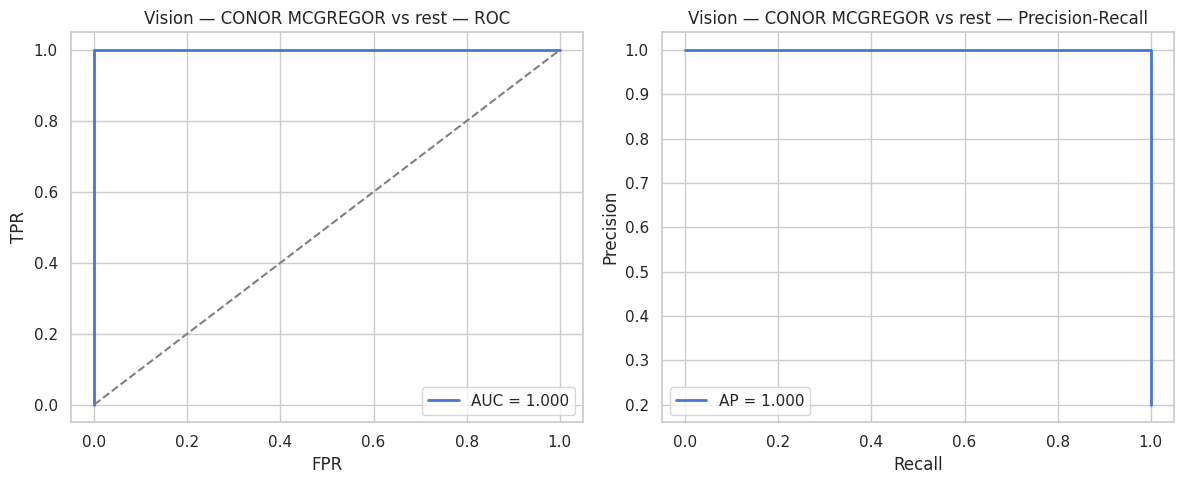

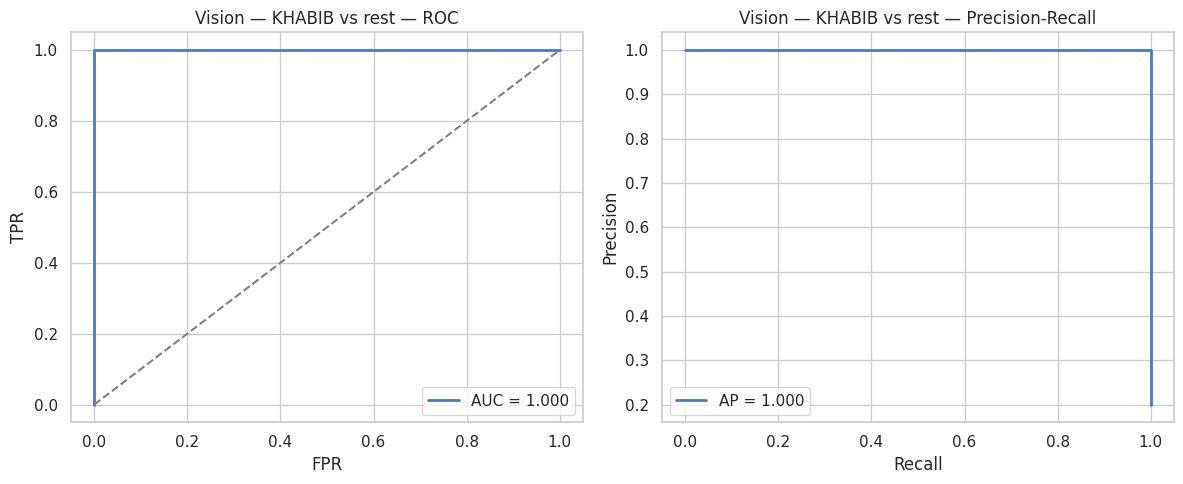

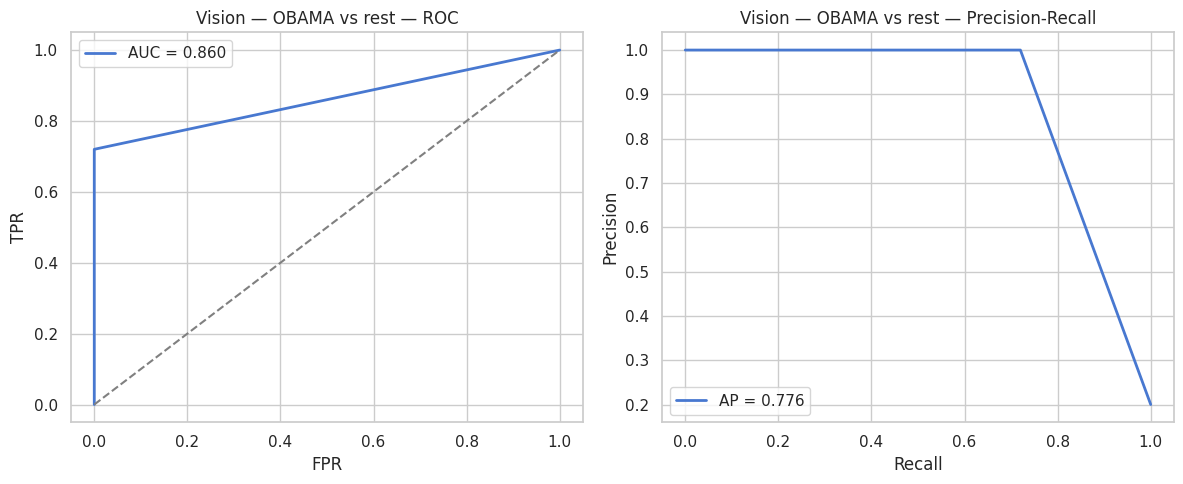

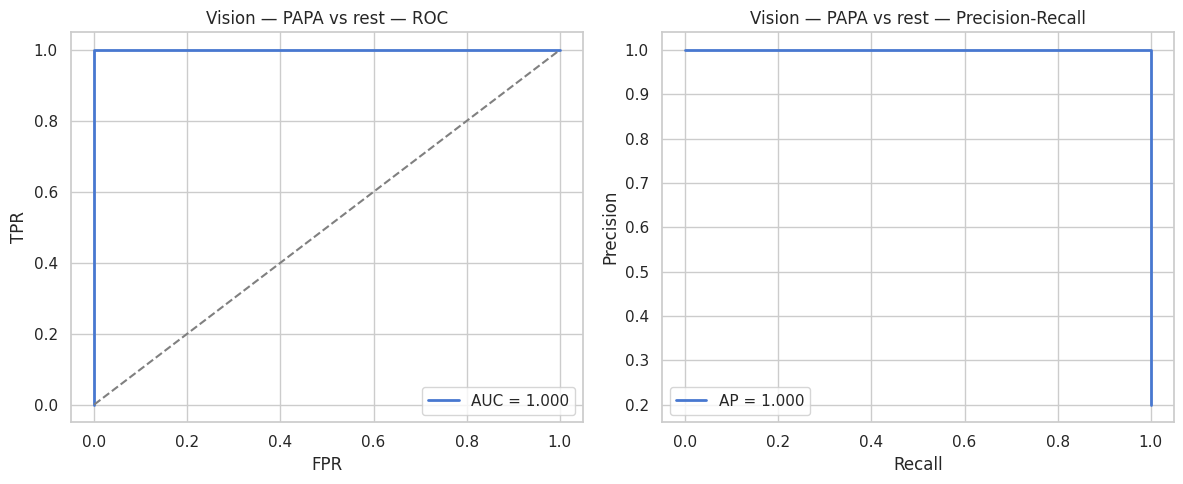

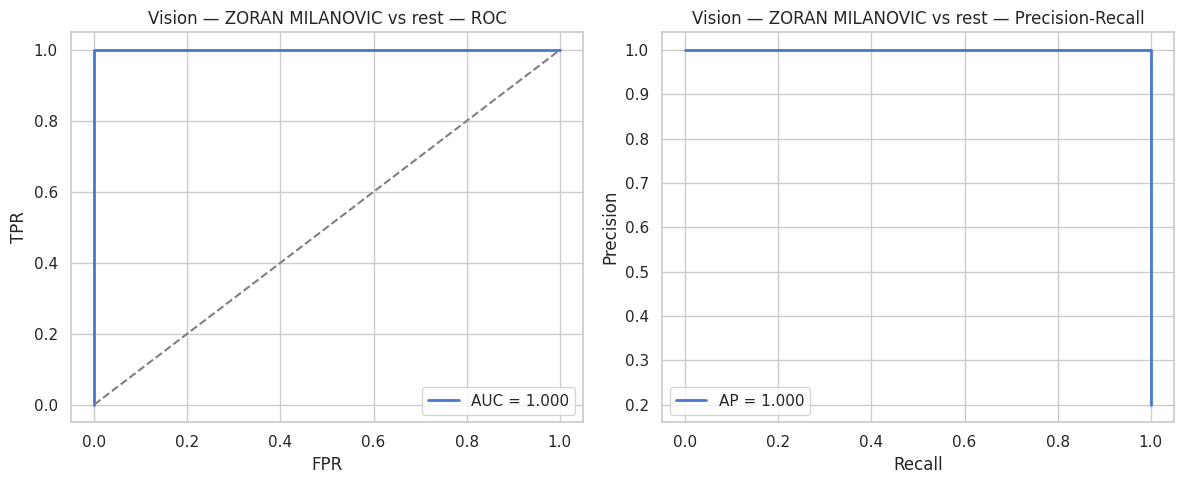


[Vision] One-vs-rest summary:


,class,positives,negatives,roc_auc,average_precision,score_source
0,CONOR MCGREGOR,25,100,1.00,1.000,fallback: top-1 pred + score
1,KHABIB,25,100,1.00,1.000,fallback: top-1 pred + score
2,PAPA,25,100,1.00,1.000,fallback: top-1 pred + score
3,ZORAN MILANOVIC,25,100,1.00,1.000,fallback: top-1 pred + score
4,OBAMA,25,100,0.86,0.776,fallback: top-1 pred + score


[Audio] Binary known/unknown ROC/PR skipped — closed-set setup has no unknown class.
[Audio] Plotting one-vs-rest ROC/PR for 5 classes.


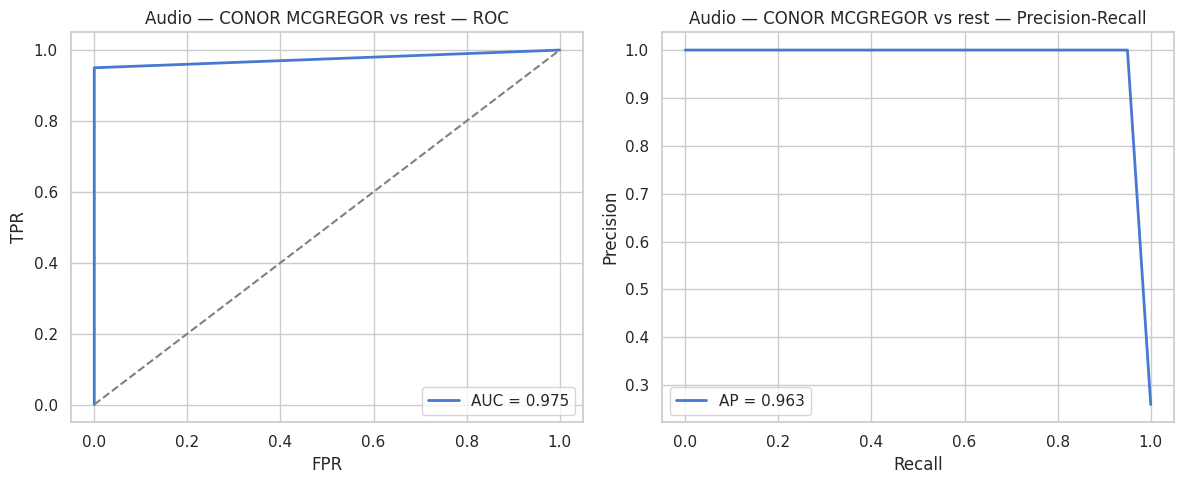

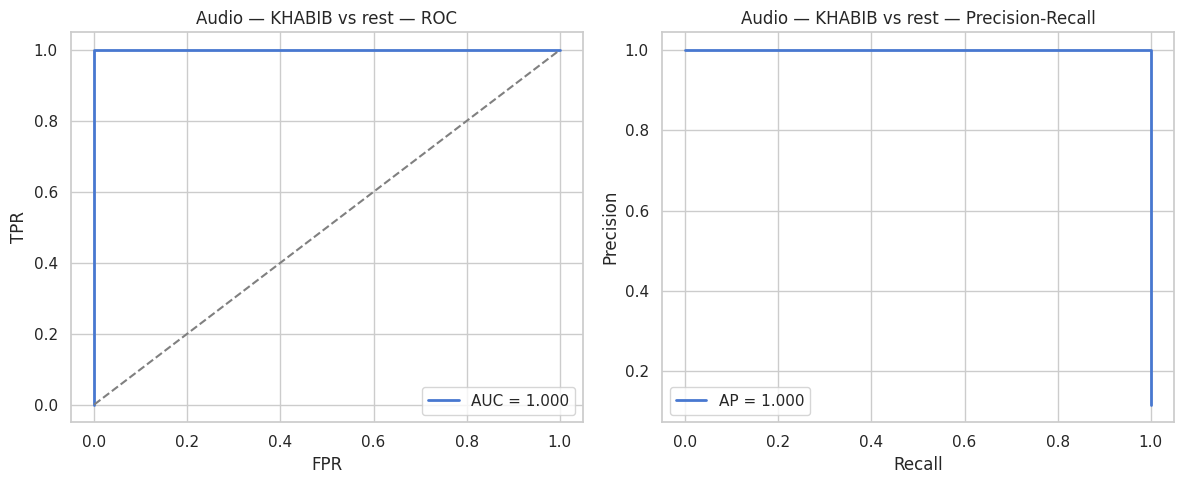

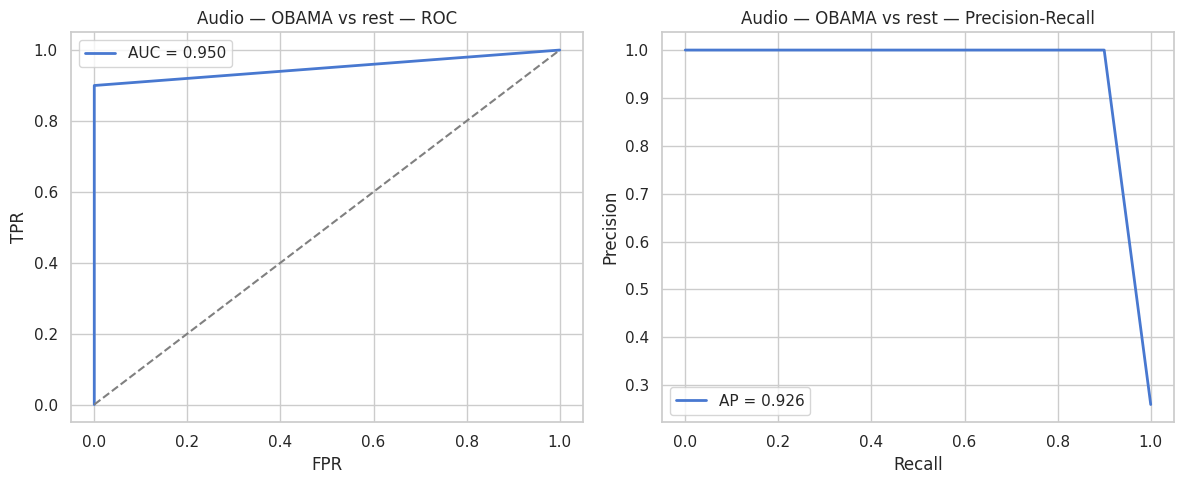

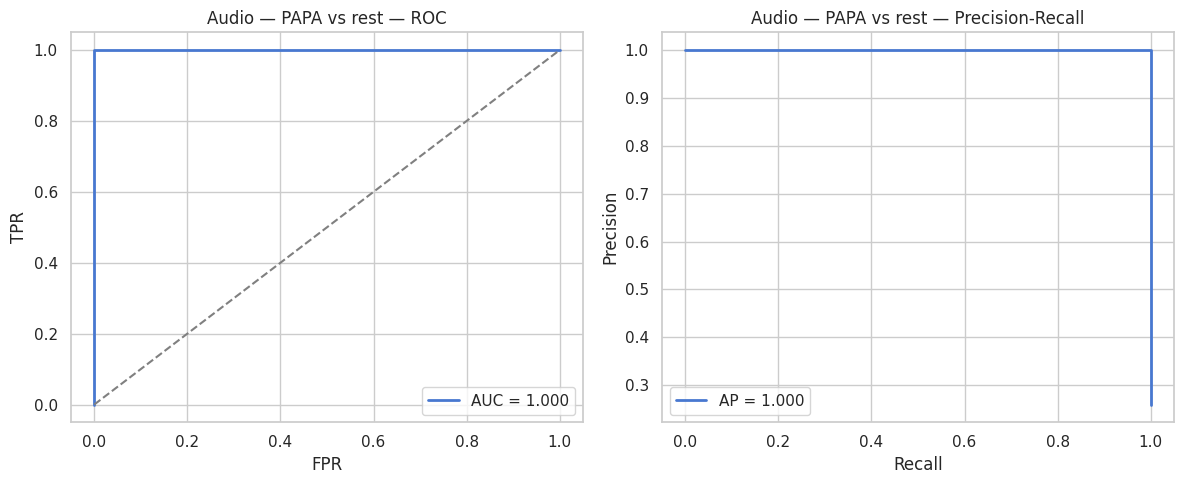

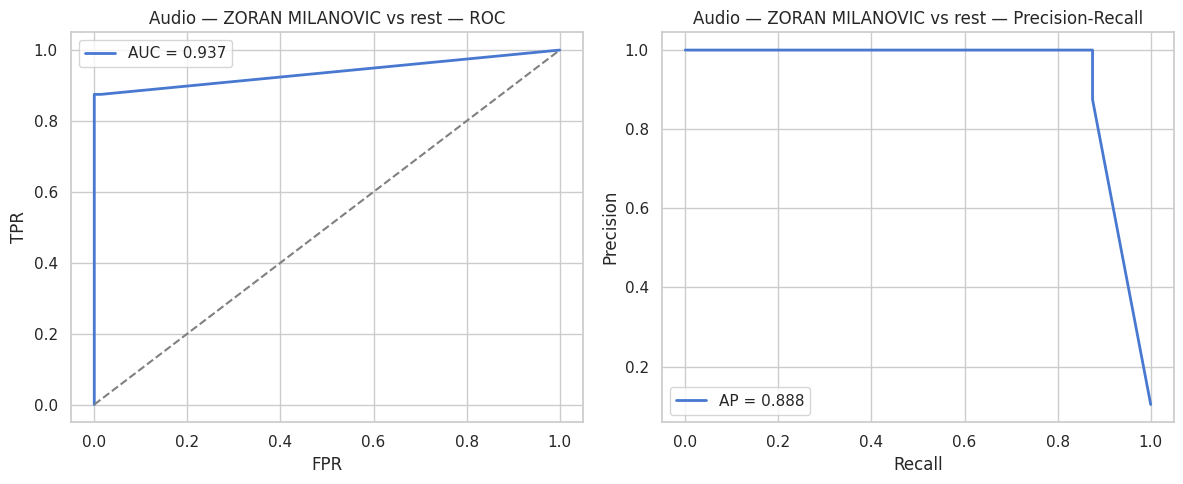


[Audio] One-vs-rest summary:


,class,positives,negatives,roc_auc,average_precision,score_source
0,KHABIB,9,68,1.000000,1.000000,fallback: top-1 pred + score
1,PAPA,20,57,1.000000,1.000000,fallback: top-1 pred + score
2,CONOR MCGREGOR,20,57,0.975000,0.962987,fallback: top-1 pred + score
3,OBAMA,20,57,0.950000,0.925974,fallback: top-1 pred + score
4,ZORAN MILANOVIC,8,69,0.936594,0.887987,fallback: top-1 pred + score


In [58]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
)


def plot_roc_pr(result_tuple, title, higher_score_is_better=True):
    if result_tuple is None:
        return

    df, labels, y_true_bin, y_pred_bin, scores = result_tuple

    def normalize_name(x):
        return re.sub(r'[^a-z0-9]+', '_', str(x).strip().lower()).strip('_')

    def show_df(x):
        try:
            display(x)
        except NameError:
            print(x)

    def bad_score_value(values):
        values = np.asarray(values, dtype=float)
        finite = values[np.isfinite(values)]

        if len(finite) == 0:
            return -1e9 if higher_score_is_better else 1e9

        eps = 1e-9
        return finite.min() - eps if higher_score_is_better else finite.max() + eps

    def orient_scores(values):
        values = np.asarray(values, dtype=float)
        return values if higher_score_is_better else -values

    def extract_from_dict(obj, cls):
        if not isinstance(obj, dict):
            return np.nan

        if cls in obj:
            return float(obj[cls])

        cls_norm = normalize_name(cls)

        for k, v in obj.items():
            if normalize_name(k) == cls_norm:
                return float(v)

        return np.nan

    def extract_from_matches(obj, cls):
        if not isinstance(obj, list):
            return np.nan

        cls_norm = normalize_name(cls)
        best = np.nan

        for item in obj:
            if not isinstance(item, dict):
                continue

            person = (
                item.get("person_id")
                or item.get("identity")
                or item.get("label")
                or item.get("class")
                or item.get("name")
            )

            if person is None or normalize_name(person) != cls_norm:
                continue

            val = (
                item.get("score")
                if item.get("score") is not None
                else item.get("similarity")
                if item.get("similarity") is not None
                else item.get("distance")
            )

            if val is None:
                continue

            val = float(val)

            if np.isnan(best):
                best = val
            elif higher_score_is_better:
                best = max(best, val)
            else:
                best = min(best, val)

        return best

    def get_class_scores(cls):
        cls_norm = normalize_name(cls)

        direct_candidates = [
            f"score_{cls}",
            f"scores_{cls}",
            f"prob_{cls}",
            f"sim_{cls}",
            f"similarity_{cls}",
            f"distance_{cls}",
            f"score_{cls_norm}",
            f"scores_{cls_norm}",
            f"prob_{cls_norm}",
            f"sim_{cls_norm}",
            f"similarity_{cls_norm}",
            f"distance_{cls_norm}",
        ]

        normalized_cols = {normalize_name(c): c for c in df.columns}

        for candidate in direct_candidates:
            candidate_norm = normalize_name(candidate)
            if candidate_norm in normalized_cols:
                col = normalized_cols[candidate_norm]
                vals = pd.to_numeric(df[col], errors="coerce").to_numpy(dtype=float)
                fill = bad_score_value(vals)
                vals = np.nan_to_num(vals, nan=fill)
                return orient_scores(vals), "per-class column"

        dict_like_cols = [
            "scores",
            "class_scores",
            "identity_scores",
            "scores_by_class",
            "score_by_class",
            "class_score",
        ]

        for col in dict_like_cols:
            if col not in df.columns:
                continue

            vals = df[col].apply(lambda x: extract_from_dict(x, cls)).to_numpy(dtype=float)

            if not np.isnan(vals).all():
                fill = bad_score_value(vals)
                vals = np.nan_to_num(vals, nan=fill)
                return orient_scores(vals), f"dict column: {col}"

        match_like_cols = [
            "matches",
            "top_matches",
            "neighbors",
            "nearest",
            "nearest_neighbors",
            "raw_matches",
        ]

        for col in match_like_cols:
            if col not in df.columns:
                continue

            vals = df[col].apply(lambda x: extract_from_matches(x, cls)).to_numpy(dtype=float)

            if not np.isnan(vals).all():
                fill = bad_score_value(vals)
                vals = np.nan_to_num(vals, nan=fill)
                return orient_scores(vals), f"matches column: {col}"

        if "pred" not in df.columns:
            return None, None

        base_scores = (
            pd.to_numeric(df["score"], errors="coerce").to_numpy(dtype=float)
            if "score" in df.columns
            else np.asarray(scores, dtype=float)
        )

        fill = bad_score_value(base_scores)
        vals = np.where(df["pred"].astype(str).to_numpy() == str(cls), base_scores, fill)

        return orient_scores(vals), "fallback: top-1 pred + score"

    def plot_pair(y_true, y_score, main_title):
        fpr, tpr, _ = roc_curve(y_true, y_score)
        roc_auc = auc(fpr, tpr)

        prec, rec, _ = precision_recall_curve(y_true, y_score)
        ap = average_precision_score(y_true, y_score)

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        axes[0].plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.3f}")
        axes[0].plot([0, 1], [0, 1], "--", color="grey")
        axes[0].set_xlabel("FPR")
        axes[0].set_ylabel("TPR")
        axes[0].set_title(f"{main_title} — ROC")
        axes[0].legend()

        axes[1].plot(rec, prec, lw=2, label=f"AP = {ap:.3f}")
        axes[1].set_xlabel("Recall")
        axes[1].set_ylabel("Precision")
        axes[1].set_title(f"{main_title} — Precision-Recall")
        axes[1].legend()

        plt.tight_layout()
        plt.show()

        return roc_auc, ap

    binary_scores = orient_scores(np.asarray(scores, dtype=float))

    if len(set(y_true_bin)) < 2:
        print(f"[{title}] Binary known/unknown ROC/PR skipped — closed-set setup has no unknown class.")
    else:
        plot_pair(
            np.asarray(y_true_bin, dtype=int),
            binary_scores,
            f"{title} — Binary known/unknown"
        )

    if "gt" not in df.columns:
        print(f"[{title}] Missing 'gt' column. Cannot plot one-vs-rest ROC/PR.")
        return

    unknown_labels = {"unknown", "none", "unrecognized", "negative", "negatives", "impostor"}

    class_names = sorted([
        c for c in df["gt"].astype(str).unique()
        if normalize_name(c) not in unknown_labels
    ])

    if len(class_names) < 2:
        print(f"[{title}] Need at least two closed-set classes for one-vs-rest ROC/PR.")
        return

    print(f"[{title}] Plotting one-vs-rest ROC/PR for {len(class_names)} classes.")

    summary_rows = []

    for cls in class_names:
        y_true = (df["gt"].astype(str).to_numpy() == str(cls)).astype(int)

        if len(set(y_true)) < 2:
            print(f"[{title}] Skipping {cls}: no positives or no negatives.")
            continue

        y_score, source = get_class_scores(cls)

        if y_score is None:
            print(f"[{title}] Skipping {cls}: no usable score column.")
            continue

        roc_auc, ap = plot_pair(
            y_true,
            y_score,
            f"{title} — {cls} vs rest"
        )

        summary_rows.append({
            "class": cls,
            "positives": int(y_true.sum()),
            "negatives": int(len(y_true) - y_true.sum()),
            "roc_auc": roc_auc,
            "average_precision": ap,
            "score_source": source,
        })

    summary = pd.DataFrame(summary_rows)

    if not summary.empty:
        summary = summary.sort_values("roc_auc", ascending=False).reset_index(drop=True)
        print(f"\n[{title}] One-vs-rest summary:")
        show_df(summary)

    return summary


vis_ovr_summary = plot_roc_pr(vis_out, "Vision")
aud_ovr_summary = plot_roc_pr(aud_out, "Audio")

In [59]:
def inspect_class_errors(result_tuple, target_class, title, top_n=20):
    if result_tuple is None:
        return

    df, *_ = result_tuple
    df = df.copy()

    df["is_target"] = df["gt"].astype(str) == str(target_class)
    df["is_correct"] = df["gt"].astype(str) == df["pred"].astype(str)

    print(f"\n{'='*70}")
    print(f"{title} — {target_class}")
    print(f"{'='*70}")

    positives = df[df["is_target"]]
    false_negatives = positives[~positives["is_correct"]]
    false_positives = df[(~df["is_target"]) & (df["pred"].astype(str) == str(target_class))]

    print(f"Total positives: {len(positives)}")
    print(f"False negatives: {len(false_negatives)}")
    print(f"False positives: {len(false_positives)}")

    print("\nPredictions for true target samples:")
    display(
        positives["pred"]
        .value_counts()
        .rename_axis("pred")
        .reset_index(name="count")
    )

    print("\nClasses falsely predicted as target:")
    display(
        false_positives["gt"]
        .value_counts()
        .rename_axis("gt")
        .reset_index(name="count")
    )

    cols = [c for c in ["gt", "pred", "score", "file"] if c in df.columns]

    print("\nFalse negatives:")
    display(false_negatives[cols].sort_values("score", ascending=False).head(top_n))

    print("\nFalse positives:")
    display(false_positives[cols].sort_values("score", ascending=False).head(top_n))


inspect_class_errors(vis_out, "OBAMA", "Vision")
inspect_class_errors(vis_out, "GARETH", "Vision")

inspect_class_errors(aud_out, "GARETH", "Audio")
inspect_class_errors(aud_out, "OBAMA", "Audio")

def inspect_all_class_errors(result_tuple, title, top_n=20, sort_by="total_errors"):
    if result_tuple is None:
        return None

    df, *_ = result_tuple
    df = df.copy()

    if "gt" not in df.columns or "pred" not in df.columns:
        print(f"[{title}] Missing 'gt' or 'pred' column.")
        return None

    classes = sorted(df["gt"].astype(str).unique())

    summary_rows = []

    for cls in classes:
        positives = df[df["gt"].astype(str) == cls]
        false_negatives = positives[positives["pred"].astype(str) != cls]
        false_positives = df[
            (df["gt"].astype(str) != cls) &
            (df["pred"].astype(str) == cls)
        ]

        summary_rows.append({
            "class": cls,
            "positives": len(positives),
            "correct": int((positives["pred"].astype(str) == cls).sum()),
            "false_negatives": len(false_negatives),
            "false_positives": len(false_positives),
            "total_errors": len(false_negatives) + len(false_positives),
            "recall": (positives["pred"].astype(str) == cls).mean() if len(positives) else 0.0,
        })

    summary = pd.DataFrame(summary_rows)

    if sort_by in summary.columns:
        summary = summary.sort_values(sort_by, ascending=False).reset_index(drop=True)

    print(f"\n{'='*70}")
    print(f"{title} — all classes error summary")
    print(f"{'='*70}")
    display(summary)

    for cls in summary["class"]:
        inspect_class_errors(
            result_tuple=result_tuple,
            target_class=cls,
            title=title,
            top_n=top_n,
        )

    return summary


vis_error_summary = inspect_all_class_errors(vis_out, "Vision", top_n=20)
aud_error_summary = inspect_all_class_errors(aud_out, "Audio", top_n=20)


Vision — OBAMA
Total positives: 25
False negatives: 7
False positives: 0

Predictions for true target samples:


,pred,count
0,OBAMA,18
1,unknown,7



Classes falsely predicted as target:


,gt,count



False negatives:


...

,gt,count
0,CONOR MCGREGOR,1



False negatives:


,gt,pred,score,file



False positives:


,gt,pred,score,file
15,CONOR MCGREGOR,KHABIB,0.558194,known_data/CONOR MCGREGOR/val/audio/CONOR MCGR...


Vision vectors: 5
Audio vectors: 5
Fusion vectors: 5


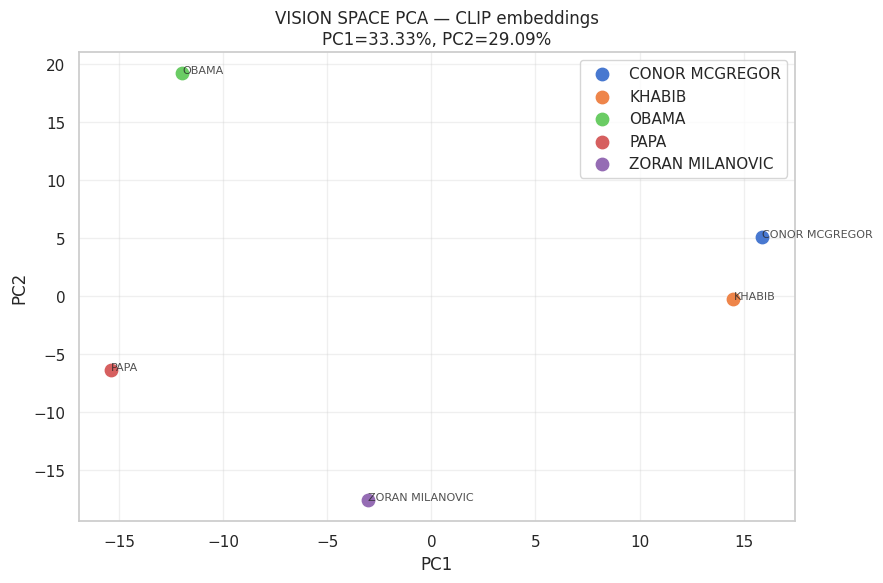

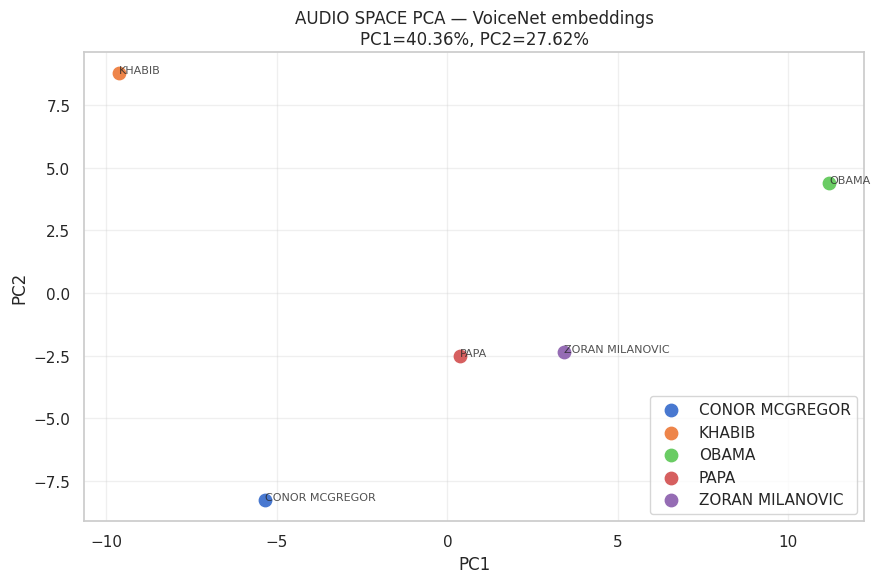

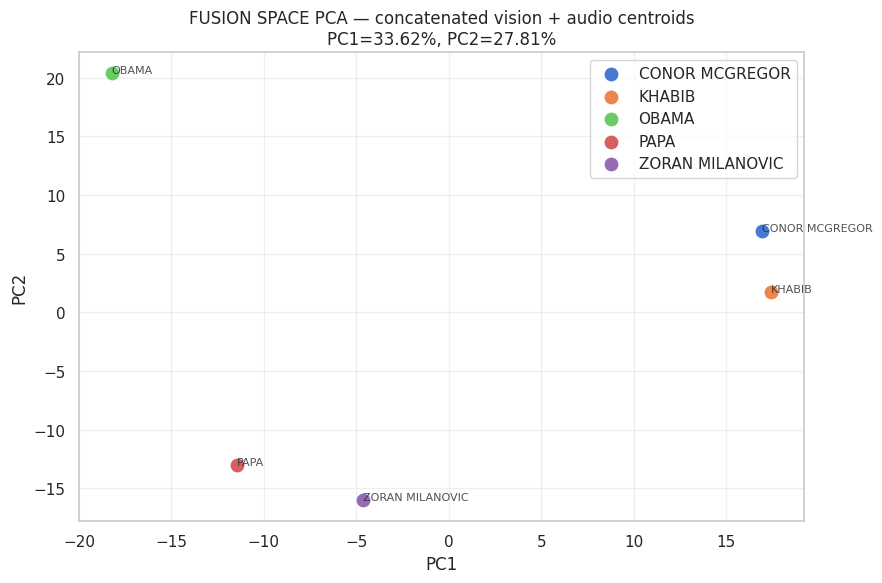

In [60]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


def fetch_vectors_from_qdrant(collection_name):
    rows = []
    offset = None

    while True:
        points, offset = client.scroll(
            collection_name=collection_name,
            limit=256,
            offset=offset,
            with_payload=True,
            with_vectors=True,
        )

        for p in points:
            payload = p.payload or {}
            vec = p.vector

            if isinstance(vec, dict):
                vec = list(vec.values())[0]

            rows.append({
                "person_id": payload.get("person_id", "unknown"),
                "organization_id": payload.get("organization_id", "unknown"),
                "modality": payload.get("modality", collection_name),
                "sample_id": payload.get("sample_id", str(p.id)),
                "vector": norm(vec),
            })

        if offset is None:
            break

    return pd.DataFrame(rows)


def plot_pca_space(df, title):
    if df is None or df.empty:
        print(f"{title}: no vectors found.")
        return None

    if len(df) < 2:
        print(f"{title}: need at least 2 vectors for PCA.")
        return None

    X = np.stack(df["vector"].values)
    y = df["person_id"].astype(str).values

    X_scaled = StandardScaler().fit_transform(X)

    pca = PCA(n_components=2)
    Z = pca.fit_transform(X_scaled)

    plot_df = pd.DataFrame({
        "PC1": Z[:, 0],
        "PC2": Z[:, 1],
        "person_id": y,
        "sample_id": df["sample_id"].astype(str).values,
    })

    plt.figure(figsize=(9, 6))

    for person_id, group in plot_df.groupby("person_id"):
        plt.scatter(group["PC1"], group["PC2"], s=80, label=person_id)

        for _, row in group.iterrows():
            plt.annotate(
                row["person_id"],
                (row["PC1"], row["PC2"]),
                fontsize=8,
                alpha=0.8,
            )

    plt.title(
        f"{title}\n"
        f"PC1={pca.explained_variance_ratio_[0]:.2%}, "
        f"PC2={pca.explained_variance_ratio_[1]:.2%}"
    )
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return plot_df


def build_fusion_vectors(face_df, voice_df):
    if face_df.empty or voice_df.empty:
        return pd.DataFrame()

    def centroids(df):
        out = {}

        for person_id, group in df.groupby("person_id"):
            X = np.stack(group["vector"].values)
            out[person_id] = norm(np.mean(X, axis=0))

        return out

    face_centroids = centroids(face_df)
    voice_centroids = centroids(voice_df)

    common_ids = sorted(set(face_centroids) & set(voice_centroids))

    rows = []

    for person_id in common_ids:
        fusion_vec = np.concatenate([
            face_centroids[person_id],
            voice_centroids[person_id],
        ])

        rows.append({
            "person_id": person_id,
            "organization_id": "fusion",
            "modality": "fusion",
            "sample_id": f"fusion_{person_id}",
            "vector": norm(fusion_vec),
        })

    return pd.DataFrame(rows)


vision_space_df = fetch_vectors_from_qdrant(FACE_COLLECTION)
audio_space_df = fetch_vectors_from_qdrant(VOICE_COLLECTION)
fusion_space_df = build_fusion_vectors(vision_space_df, audio_space_df)

print("Vision vectors:", len(vision_space_df))
print("Audio vectors:", len(audio_space_df))
print("Fusion vectors:", len(fusion_space_df))

vision_pca_df = plot_pca_space(
    vision_space_df,
    "VISION SPACE PCA — CLIP embeddings"
)

audio_pca_df = plot_pca_space(
    audio_space_df,
    "AUDIO SPACE PCA — VoiceNet embeddings"
)

fusion_pca_df = plot_pca_space(
    fusion_space_df,
    "FUSION SPACE PCA — concatenated vision + audio centroids"
)

## 15 — Export all results to Excel

In [ ]:
import datetime

timestamp = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
out_path  = f'eval_results_{timestamp}.xlsx'

with pd.ExcelWriter(out_path, engine='openpyxl') as writer:
    if vis_out:
        vis_out[0].to_excel(writer, sheet_name='Vision_Raw',  index=False)
        if vis_table is not None:
            vis_table.to_excel(writer, sheet_name='Vision_PerIdentity', index=False)
    if aud_out:
        aud_out[0].to_excel(writer, sheet_name='Audio_Raw',   index=False)
        if aud_table is not None:
            aud_table.to_excel(writer, sheet_name='Audio_PerIdentity',  index=False)
    if 'fusion_df' in dir() and fusion_df is not None:
        fusion_df.to_excel(writer, sheet_name='Fusion', index=False)

print(f'Results saved to {out_path}')